# Project 2
## Lawrence Liu Jackie McGinley

# Background
#### A large company named Canterra, employs, at any given point of time, around 4000 employees. However, every year, around 15% of its employees leave the company and need to be replaced with the talent pool available in the job market. The management believes that this level of attrition (employees leaving, either on their own or because they got fired) is bad for the company, because of the following reasons:
- The former employees’ projects get delayed, which makes it difficult to meet timelines, resulting in a reputation loss among consumers and partners
- A sizable department has to be maintained, for the purposes of recruiting new talent
- More often than not, the new employees have to be trained for the job and/or given time to acclimatize themselves to the company
#### The management hypothesizes that higher job satisfaction and a higher number of total working years will reduce employee attrition. Additionally, the marketing management was interested to know if demographic variables such as gender, education and age affect employee attrition. Hence, the management has contracted you as a consultant to understand whether these two factors they should focus on, in order to curb attrition. In other words, they want to know if changes in their internal and external recruitment strategies would help retain employees.



---

#### Import the important libraries needed for analysis and visualizations

### Step 0: Setup
#### Load any libraries used for this project

---

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

#### For Stepwise Selection later

---

In [113]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression

#### First check to see if the data set has nulls

---

#### Step 1: Pre-Processing

---

In [209]:
print("Do we have missing values? Look at 'Non-Null Count'")
df = pd.read_excel('Employee_Data_Project.xlsx')
df.shape
print(df.info())


Do we have missing values? Look at 'Non-Null Count'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   DistanceFromHome         4410 non-null   int64  
 4   Education                4410 non-null   int64  
 5   EmployeeID               4410 non-null   int64  
 6   Gender                   4410 non-null   object 
 7   JobLevel                 4410 non-null   int64  
 8   MaritalStatus            4410 non-null   object 
 9   Income                   4410 non-null   int64  
 10  NumCompaniesWorked       4391 non-null   float64
 11  StandardHours            4410 non-null   int64  
 12  TotalWorkingYears        4401 non-null   float64
 13  TrainingTimesLastYear    4

Exception ignored in: <function ResourceTracker.__del__ at 0x102e099e0>
Traceback (most recent call last):
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106a099e0>
Traceback (most recent call last):
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
Chi

---

#### Visualize some of these rows

#### There are missing values in the NumCompaniesWorked , TotalWorkingYears , EnvironmentSatisfaction , JobSatisfaction Columns

---

#### Step 1: Pre-Processing (check rows with nulls and visualize those rows)

---

#### First step is to get the index of where the nulls are and take a look at only those rows

In [206]:
null_rows = df[df.isnull().any(axis=1)].index

#### Use the index from null rows to view those rows

In [207]:
df.loc[null_rows]

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,EmployeeID,Gender,JobLevel,MaritalStatus,Income,NumCompaniesWorked,StandardHours,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction
11,36,No,Travel_Rarely,28,1,12,Male,1,Married,33770,0.0,8,16.0,2,15,11,NaN,4.0
23,42,No,Travel_Rarely,4,4,24,Male,1,Married,89260,1.0,8,NaN,4,20,6,2.0,3.0
40,36,No,Travel_Frequently,8,3,41,Female,3,Married,69620,4.0,8,4.0,2,1,0,3.0,NaN
111,31,No,Travel_Rarely,1,3,112,Male,4,Single,28670,0.0,8,3.0,5,2,2,NaN,2.0
115,27,No,Travel_Rarely,2,3,116,Male,1,Divorced,23670,NaN,8,5.0,2,5,4,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4226,36,No,Travel_Rarely,2,3,4227,Male,2,Married,43200,NaN,8,5.0,2,1,0,2.0,4.0
4332,31,No,Travel_Rarely,2,5,4333,Male,2,Married,27280,8.0,8,7.0,3,4,2,NaN,4.0
4345,43,No,Non-Travel,6,2,4346,Male,1,Divorced,20280,4.0,8,7.0,2,5,2,4.0,NaN
4395,40,No,Travel_Rarely,2,3,4396,Male,1,Divorced,27180,NaN,8,9.0,4,9,7,1.0,4.0


---

#### Confirmed that there are truly NaNs (73 total rows have NaNs)

- 1.65% of the data is missing, to will do train-test split then impute the missing values. 

---

- Replaced the null values in the following columns with the median as they were numerical data types:
  - NumCompaniesWorked
  - TotalWorkingYears
  - EnvironmentSatisfaction
  - JobSatisfaction

---

#### Encode Attrition 


- Categorical Columns: 
  - BusinessTravel
  - Gender
  - MaritalStatus
- Numerical Columns: 
  - Age
  - DistanceFromHome
  - Education
  - Gender
  - JobLevel
  - Income
  - NumCompaniesWorked
  - TotalWorkingYears
  - TrainingTimesLastYear
  - YearsAtCompany
  - YearsWithCurrManager
  - EnvironmentSatisfaction
  - JobSatisfaction

#### Regarding the newly enconded columns 
- Gender:
  - When Gender_Male = 1, then Male
  - When Gender_Male = 0, then Female
- Marital Status:
  - When MaritalStatus_Married = 1, then Married
  - When MaritalStatus_Single = 1, then Single
  - When both MaritalStatus_Married = 0 and MaritalStatus_Single =  0, then Divorced
- Business Travel:
  - When BusinessTravel_Travel_Frequently = 1, then Travel Frequently
  - When BusinessTravel_Travel_Rarely = 1, then Travel Rarely
  - When both BusinessTravel_Travel_Frequently = 0 and BusinessTravel_Travel_Rarely = 0, then Non-Travel

---

#### Now that the categorical variables are encoded, the numerical columns will be defined (possbly min-max scaling)

---

In [208]:
numerical_columns = ['Age', 'DistanceFromHome' , 'Education' , 'Gender', 'JobLevel' , 'Income' , 
'NumCompaniesWorked' , 'TotalWorkingYears' , 'TrainingTimesLastYear' , 'YearsAtCompany' , 'YearsWithCurrManager' ,
 'EnvironmentSatisfaction', 'JobSatisfaction']

---

# Project Code Questions

---

#### Q1: Logistic Regression Rationale
- Explain why logistic regression is an appropriate modeling technique for predicting employee attrition in this dataset compared to classical regression methods. 
    - Logistic regression is an appropriate modeling technique for predicting employee attrition in this data set compared to classical regression method because Logistic Regression naturally handles the binary outcome associated with attrition(Yes/No or 1/0), supplies probability scores that can be interpreted during the decision-making processes of HR, works well with mixed variable types which are common in HR data, and provides robust statistical inference for determining factors of attrition. 

    
- Provide a specific rationale for utilizing logistic regression in predicting attrition concerning the age of employees. 

In [118]:
df = pd.read_excel('Employee_Data_Project.xlsx')
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DistanceFromHome', 'Education',
       'EmployeeID', 'Gender', 'JobLevel', 'MaritalStatus', 'Income',
       'NumCompaniesWorked', 'StandardHours', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'YearsAtCompany', 'YearsWithCurrManager',
       'EnvironmentSatisfaction', 'JobSatisfaction'],
      dtype='object')

---

#### We know that there are nulls in the dataset
- We will replace the numerical columns with the median 
- We will replace the categorical columns with the most frequent

---

#### Train-Test Split

---

In [119]:
attrition_train , attrition_test = train_test_split( 
    df, 
    test_size = 0.3, 
    random_state = 42,
    stratify= df['Attrition']
)


In [120]:
attrition_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3087 entries, 2685 to 1125
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      3087 non-null   int64  
 1   Attrition                3087 non-null   object 
 2   BusinessTravel           3087 non-null   object 
 3   DistanceFromHome         3087 non-null   int64  
 4   Education                3087 non-null   int64  
 5   EmployeeID               3087 non-null   int64  
 6   Gender                   3087 non-null   object 
 7   JobLevel                 3087 non-null   int64  
 8   MaritalStatus            3087 non-null   object 
 9   Income                   3087 non-null   int64  
 10  NumCompaniesWorked       3072 non-null   float64
 11  StandardHours            3087 non-null   int64  
 12  TotalWorkingYears        3080 non-null   float64
 13  TrainingTimesLastYear    3087 non-null   int64  
 14  YearsAtCompany           3

---

#### First, we will use simple median imputation to replace nulls for the numerical columns

---

In [121]:
medians = {'NumCompaniesWorked': df['NumCompaniesWorked'].median(), 'TotalWorkingYears': df['TotalWorkingYears'].median(),
    'EnvironmentSatisfaction': df['EnvironmentSatisfaction'].median(), 'JobSatisfaction': df['JobSatisfaction'].median()}
attrition_train = attrition_train.fillna(medians)
attrition_test = attrition_test.fillna(medians)


In [122]:
attrition_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3087 entries, 2685 to 1125
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      3087 non-null   int64  
 1   Attrition                3087 non-null   object 
 2   BusinessTravel           3087 non-null   object 
 3   DistanceFromHome         3087 non-null   int64  
 4   Education                3087 non-null   int64  
 5   EmployeeID               3087 non-null   int64  
 6   Gender                   3087 non-null   object 
 7   JobLevel                 3087 non-null   int64  
 8   MaritalStatus            3087 non-null   object 
 9   Income                   3087 non-null   int64  
 10  NumCompaniesWorked       3087 non-null   float64
 11  StandardHours            3087 non-null   int64  
 12  TotalWorkingYears        3087 non-null   float64
 13  TrainingTimesLastYear    3087 non-null   int64  
 14  YearsAtCompany           3

---

#### Now that the dataset has been split 
- Check to see if the dataset is evenly distributed
  - If the dataset is imbalanced, then we need to rebalance prior to logistic regression
- The Attrition label needs to be mapped from a categorical variable to a Boolean: 0 and 1 
- similary

---

In [123]:
attrition_train['Attrition_lab'] = (attrition_train['Attrition'] == "Yes").astype(int)
attrition_test['Attrition_lab'] = (attrition_test['Attrition'] == "Yes").astype(int)
categorical_columns = ['BusinessTravel', 'Gender', 'MaritalStatus']
attrition_train = pd.get_dummies(attrition_train, columns=categorical_columns, drop_first=True, dtype=int)
attrition_test = pd.get_dummies(attrition_test, columns = categorical_columns, drop_first= True, dtype = int )


---

- Attrition:
  - When Attrition_lab = 1, then Yes
  - When 0, then No
- Gender:
  - When Gender_Male = 1, then Male
  - Gender_Male = 0, then Female
- Marital Status:
  - When MaritalStatus_Married = 1, then Married 
  - When MaritalStatus_Single = 1, then Single 
  - When both MaritalStatus_Married = 0 and MaritalStatus_Single = 0, then Divorced
- Business Travel:
  - When BusinessTravel_Travel_Frequently = 1, then Travel Frequently
  - When BusinessTravel_Travel_Rarely = 1, then Travel Rarely 
  - When both BusinessTravel_Travel_Frequently = 0 and BusinessTravel_Travel_Rarely = 0, then Non Travel

---

#### Visualize what distribution of Attrition (response variable)

---

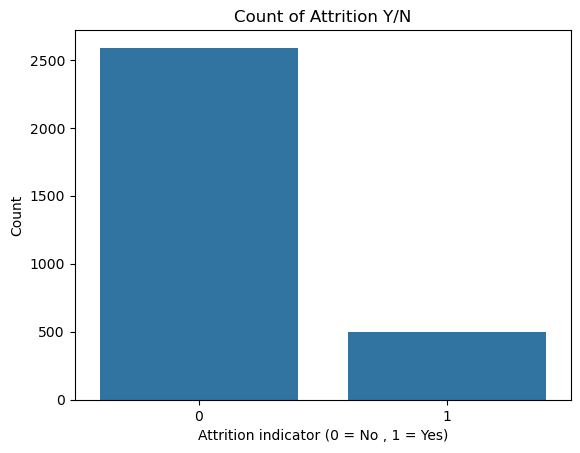

In [124]:
sns.countplot(data = attrition_train, x = 'Attrition_lab')
plt.xlabel('Attrition indicator (0 = No , 1 = Yes)')
plt.ylabel('Count')
plt.title('Count of Attrition Y/N')
plt.show()

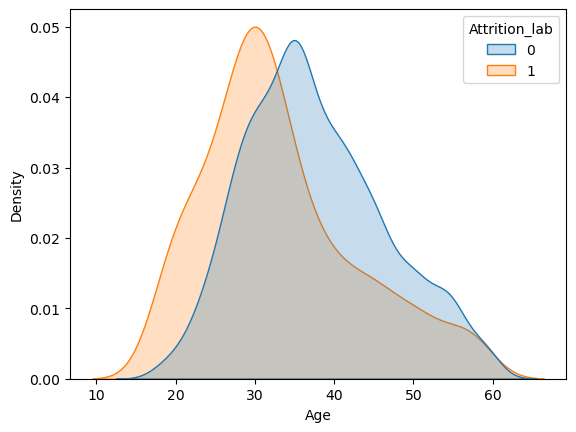

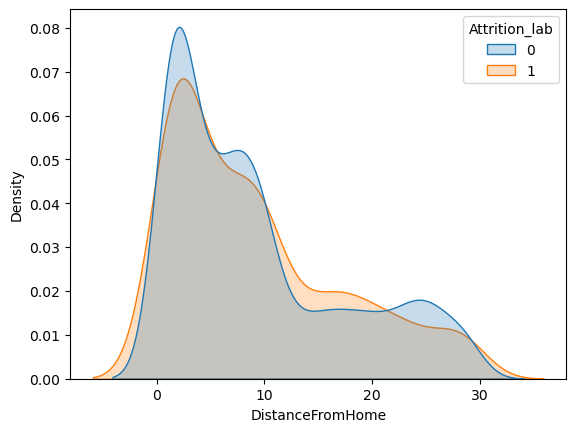

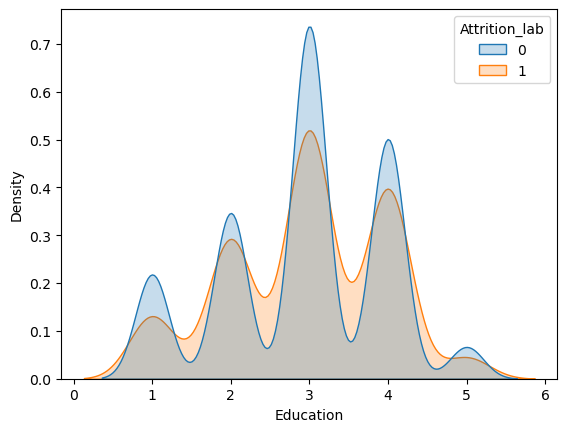

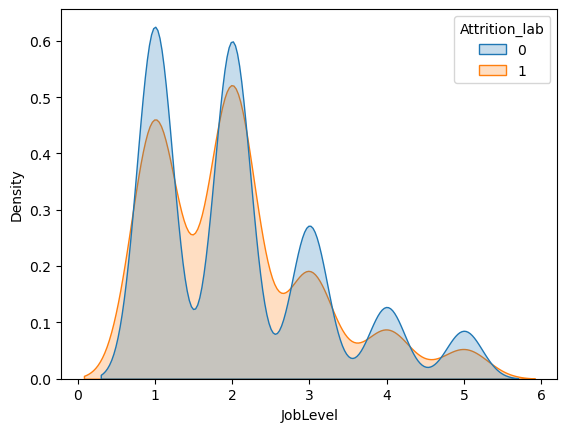

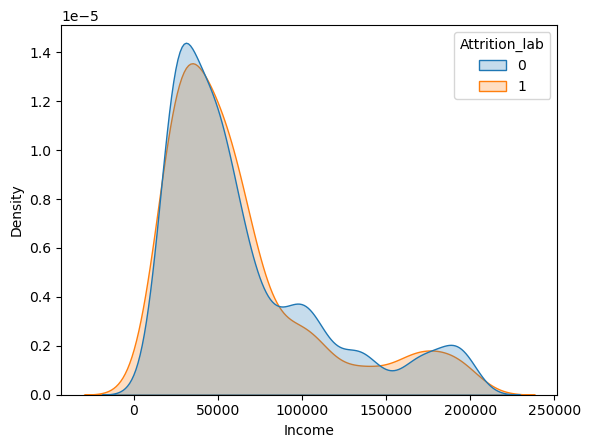

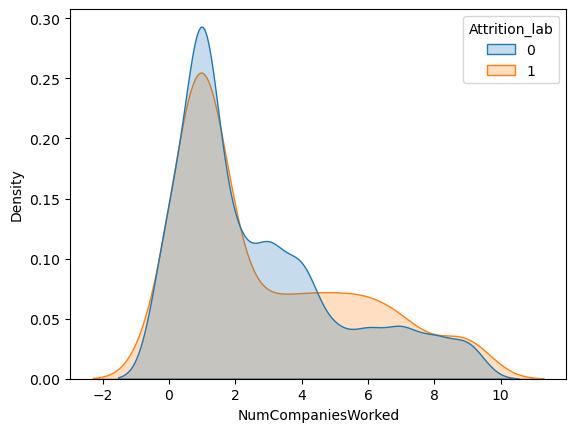

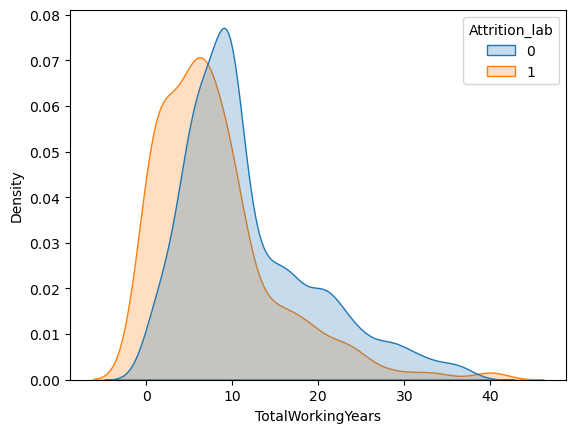

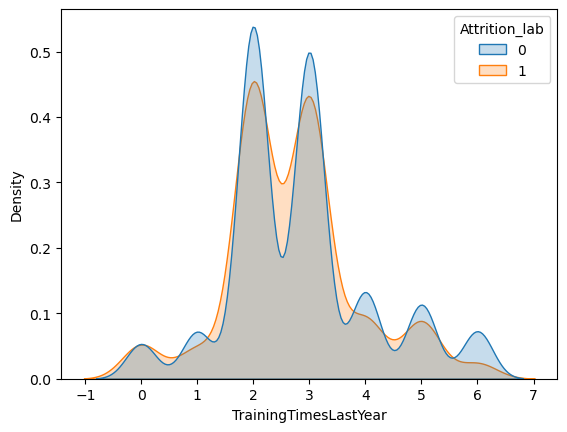

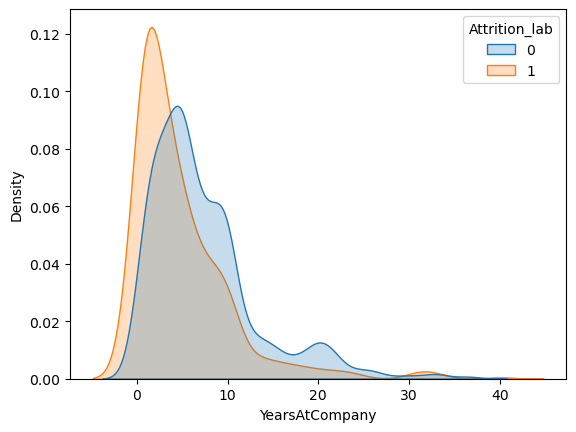

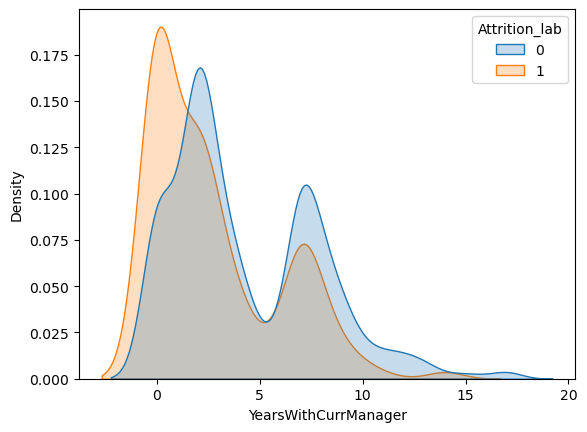

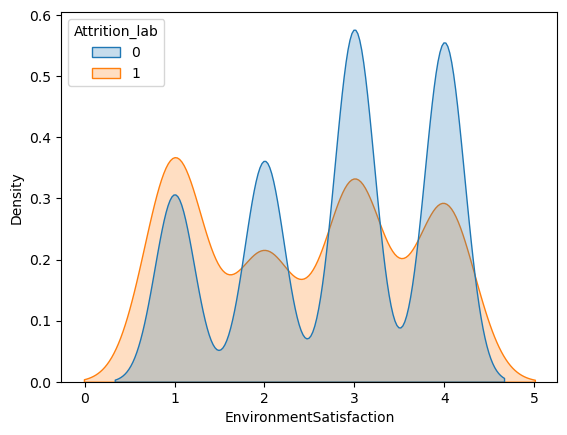

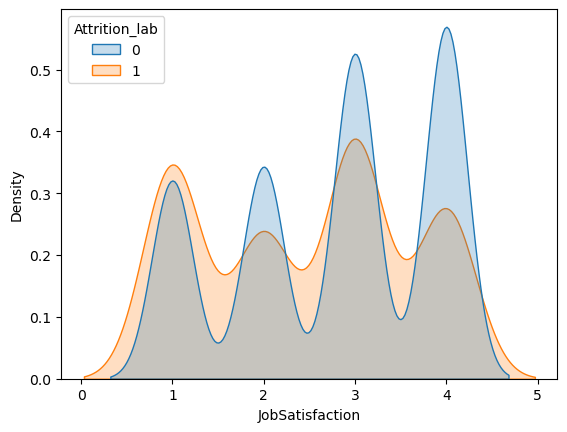

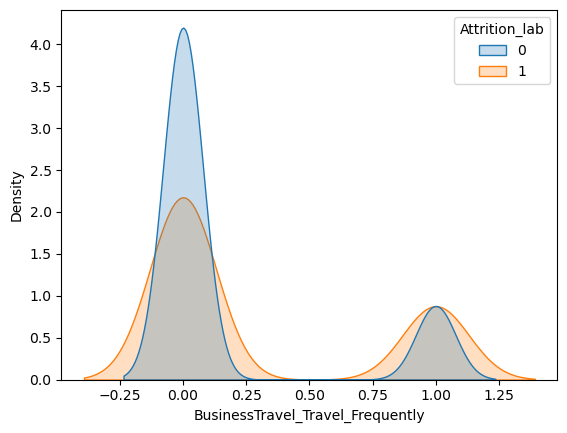

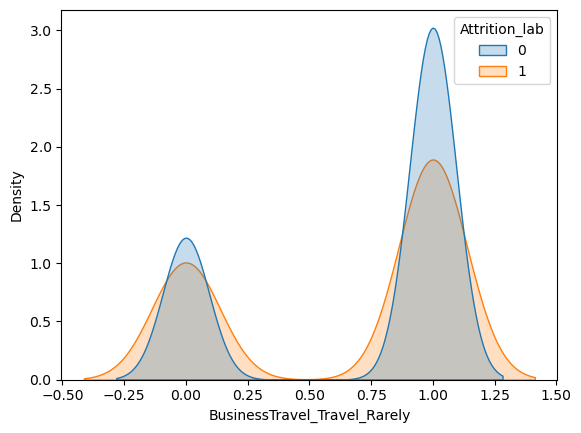

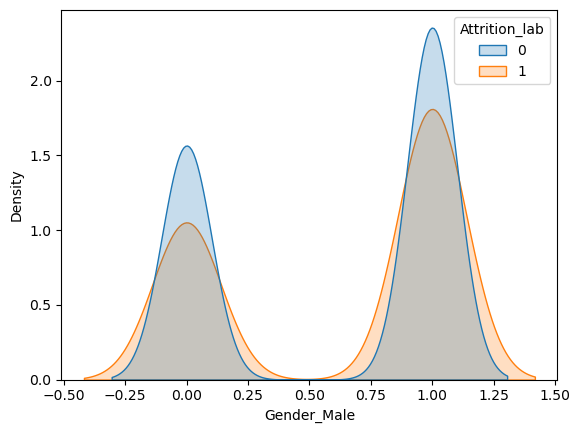

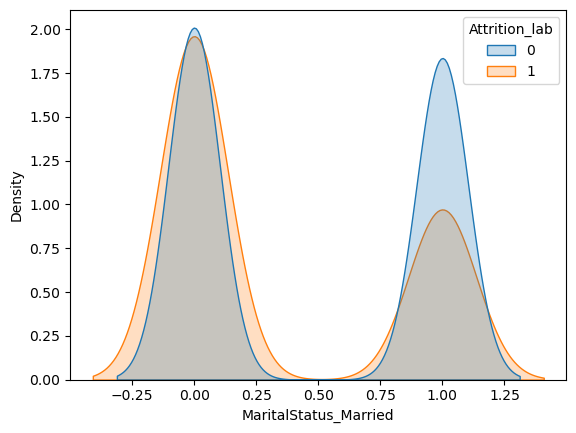

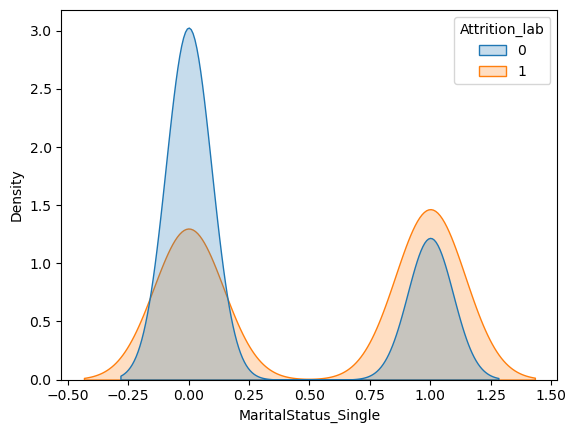

In [125]:
all_features = ['Age', 'DistanceFromHome', 'Education',
'JobLevel', 'Income', 'NumCompaniesWorked','TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'BusinessTravel_Travel_Frequently',
'BusinessTravel_Travel_Rarely', 'Gender_Male', 'MaritalStatus_Married', 'MaritalStatus_Single']

for i in all_features:
    sns.kdeplot(
        data = attrition_train,
        x = i,
        hue = 'Attrition_lab',
        fill = True,
        common_norm = False
    )   
    plt.show()

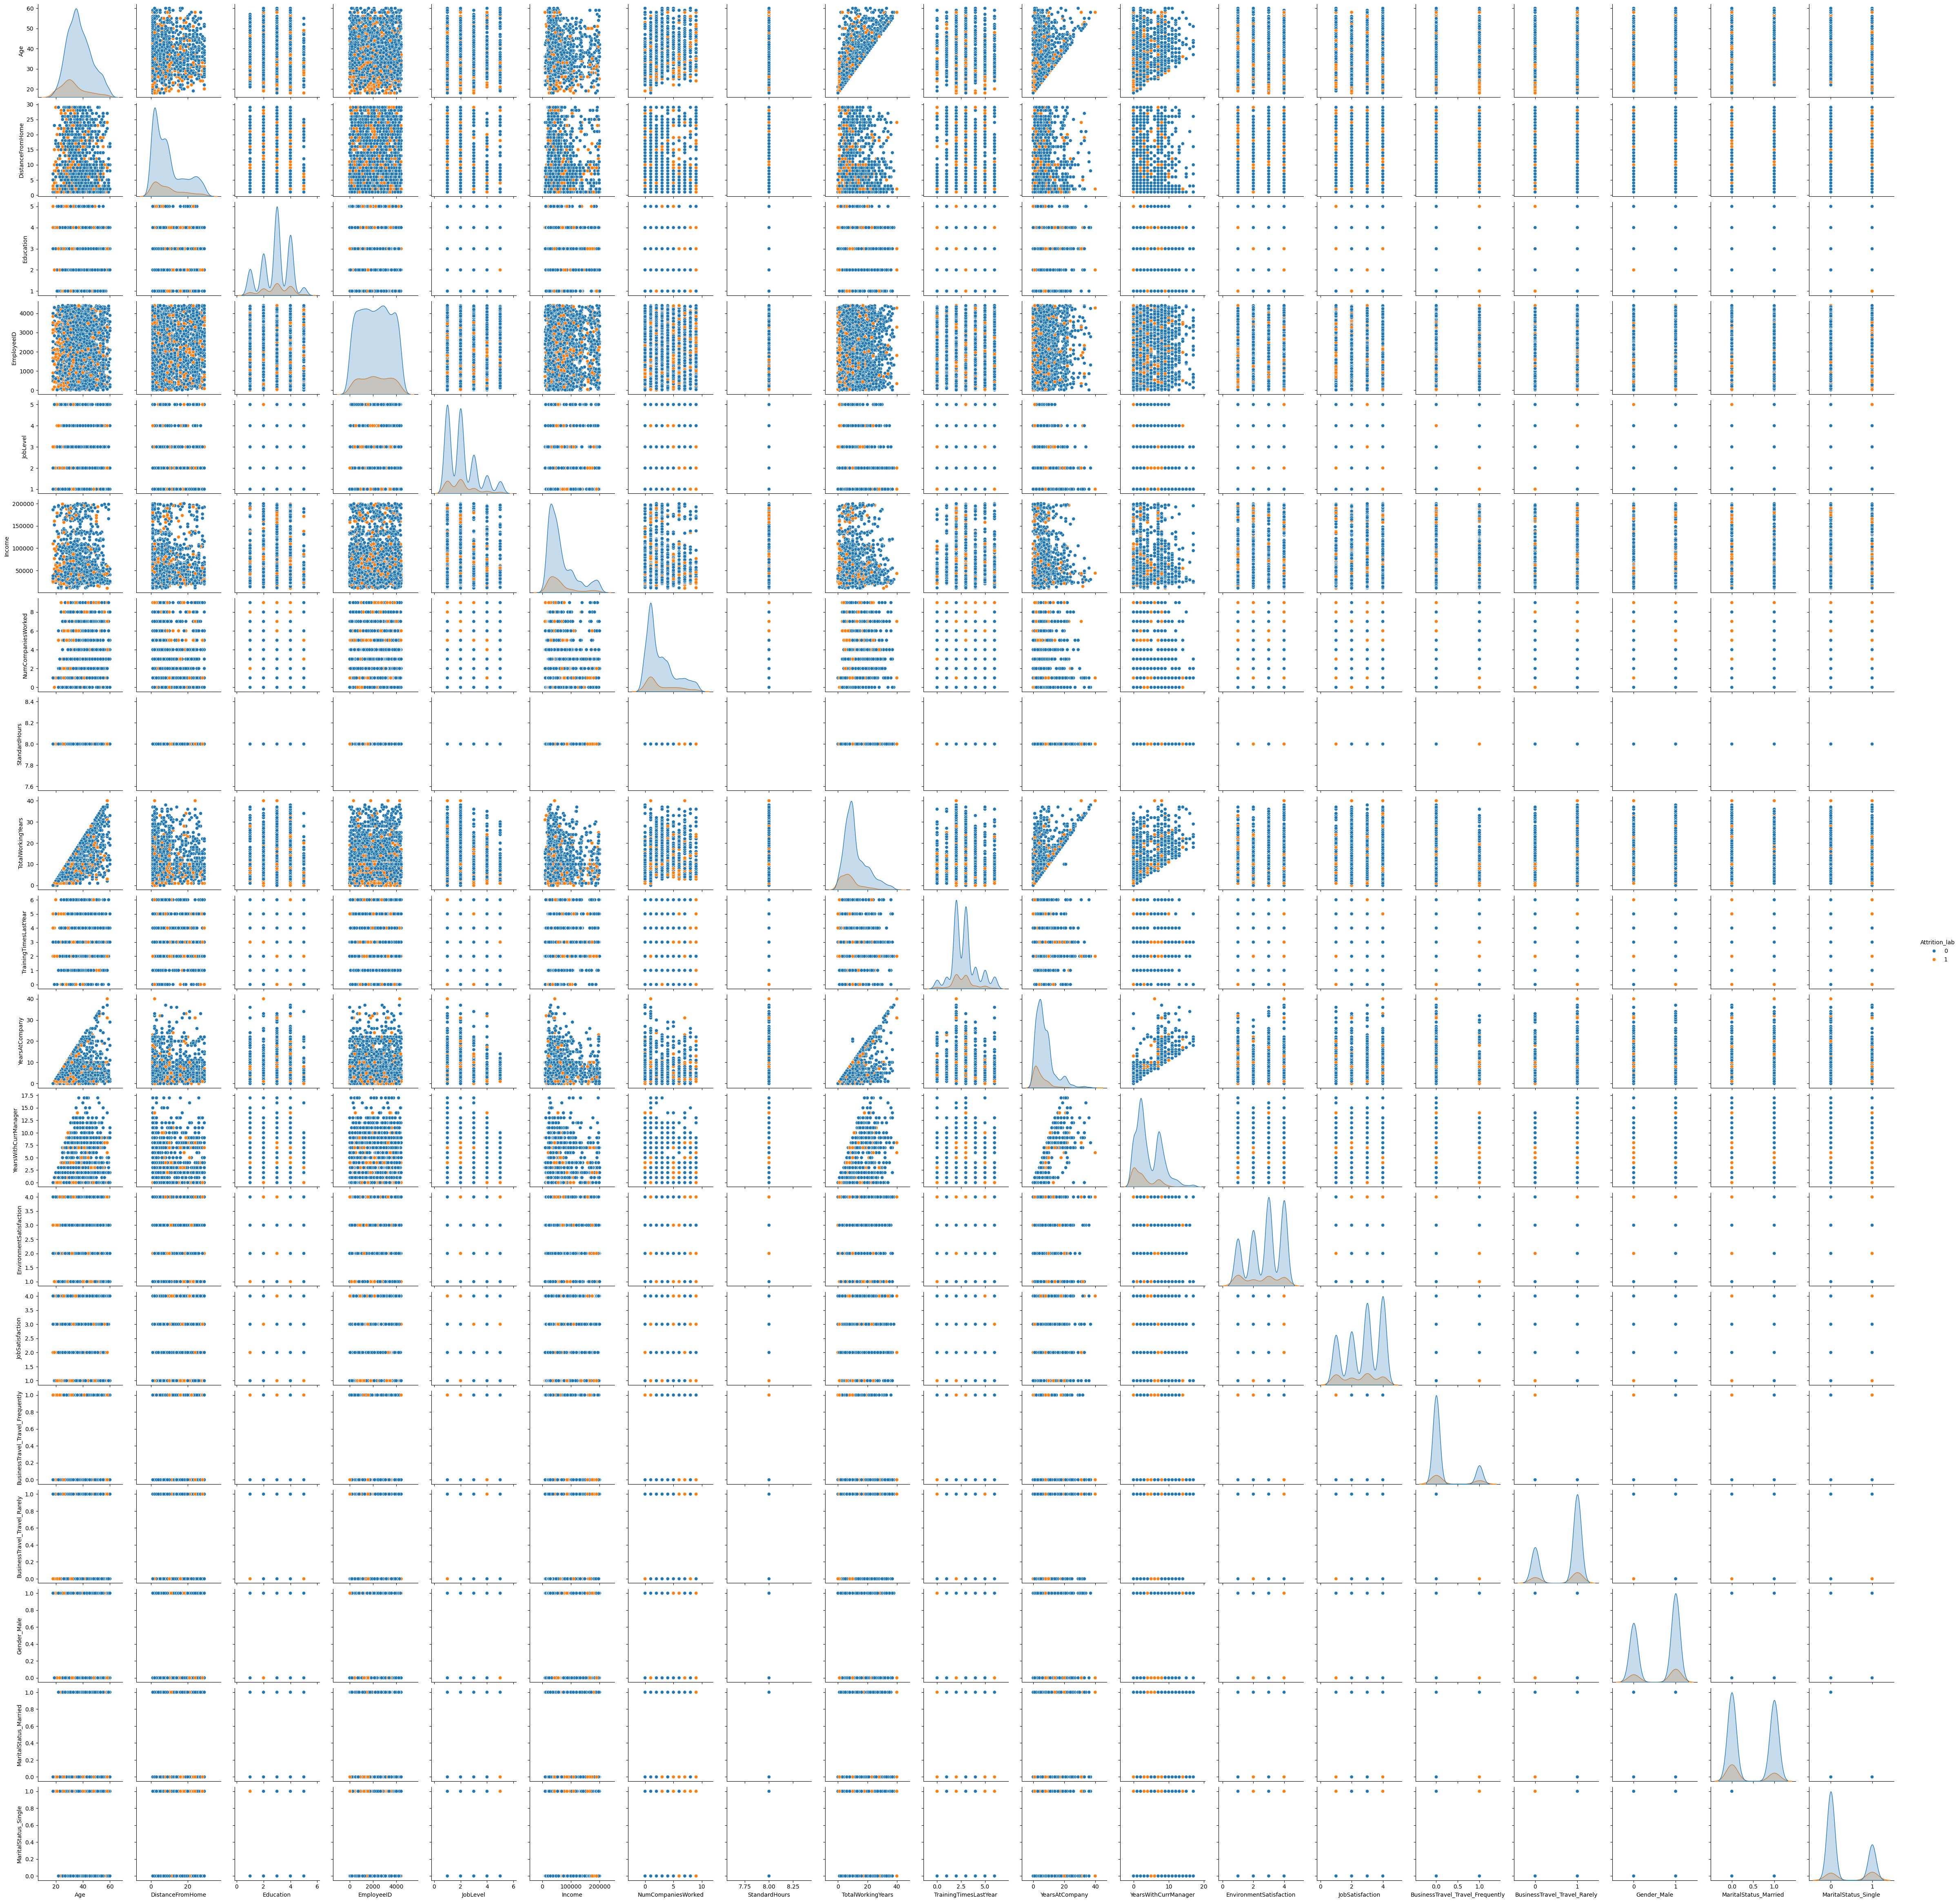

In [126]:
sns.pairplot(
    attrition_train,
    hue ='Attrition_lab',
    diag_kind = 'kde'
)
plt.show()

---

#### Based on the above Countplot and the Density Plots we can see that the dataset is highly imbalanced
- will need to rebalance the dataset (downsample)

---

#### To ensure reproducibility of our downsampling, a random seed of 42 will be used

In [127]:
np.random.seed(42)

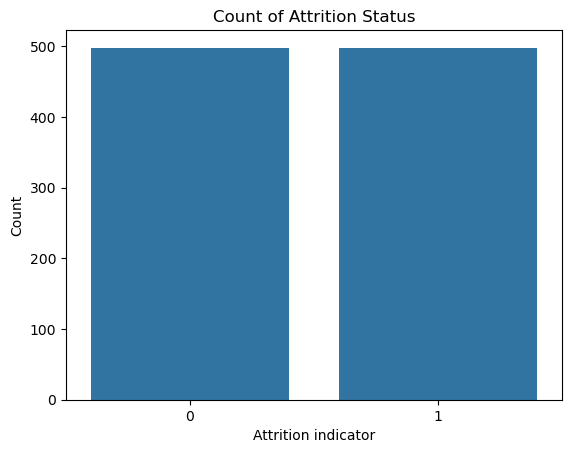

In [128]:
# Class imbalance: downsample the negative class; keep all positives
# + equal number of negatives

pos_idx = attrition_train.index[attrition_train["Attrition_lab"] == 1]
neg_idx = attrition_train.index[attrition_train["Attrition_lab"] == 0]

keep_neg = np.random.choice(neg_idx, size=len(pos_idx), replace=False)
keep_idx = np.concatenate([pos_idx, keep_neg])

attrition_train_bal = attrition_train.loc[keep_idx].copy()

# Quick look after balancing
sns.countplot(data = attrition_train_bal, x="Attrition_lab")
plt.xlabel("Attrition indicator")
plt.ylabel("Count")
plt.title("Count of Attrition Status")
plt.show()

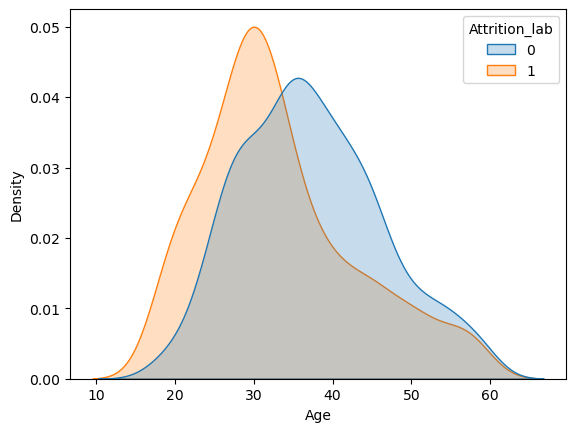

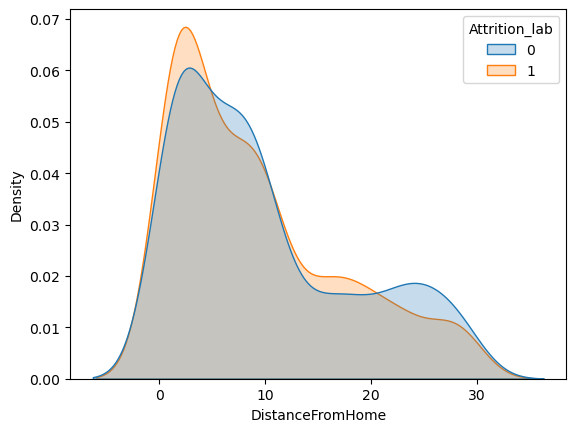

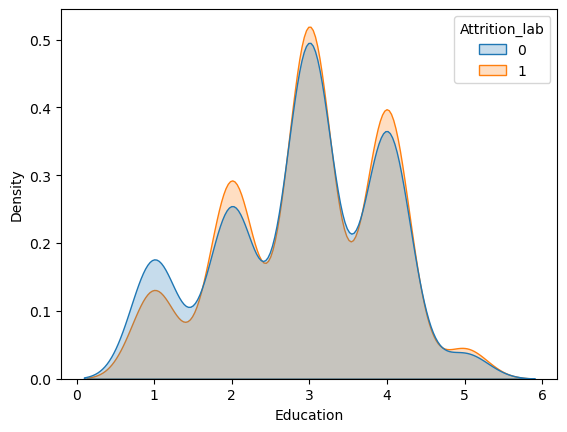

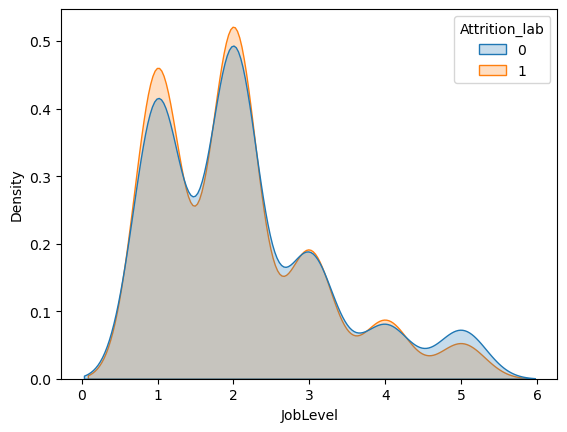

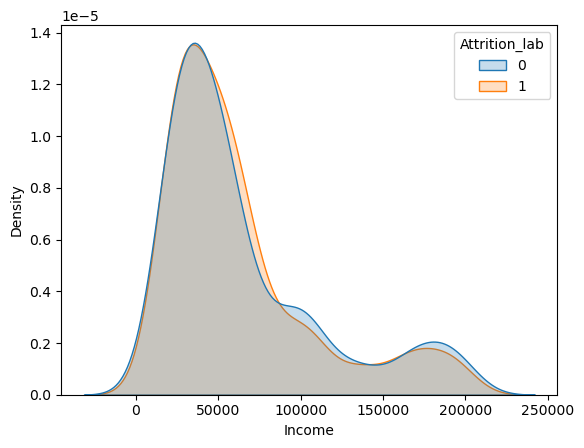

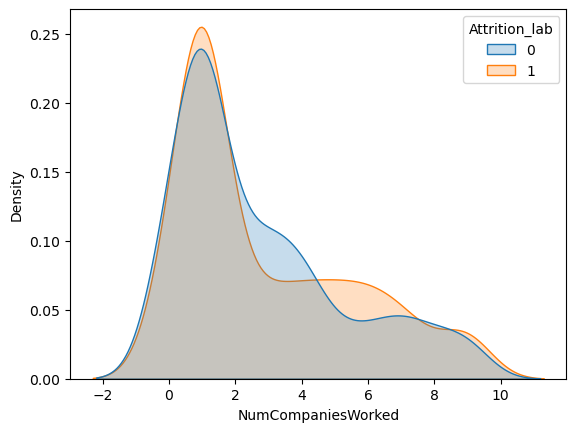

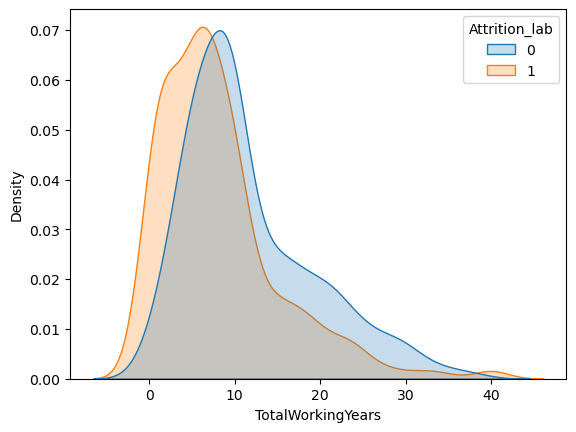

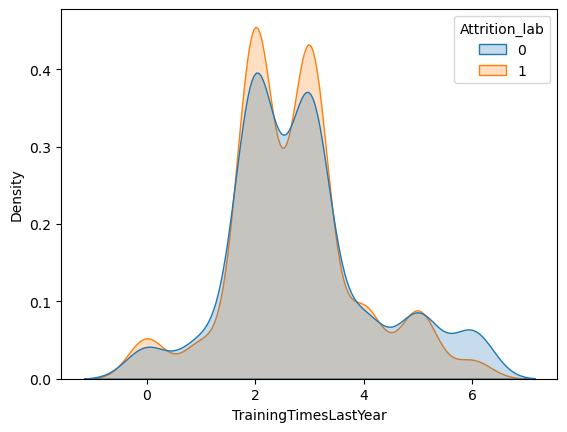

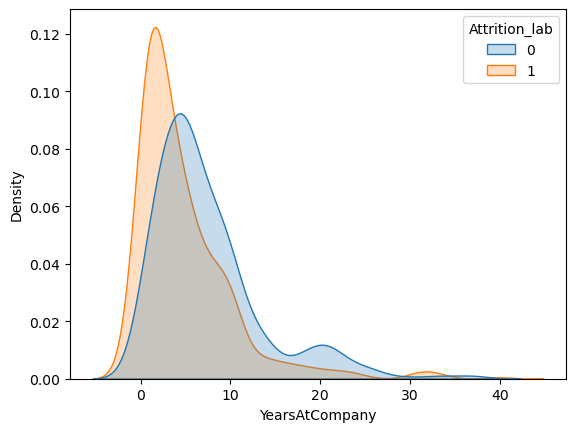

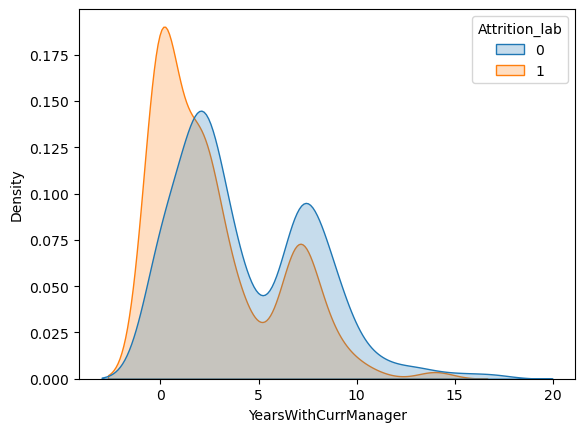

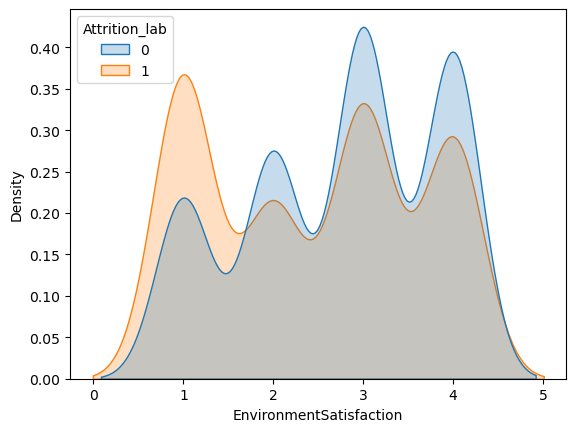

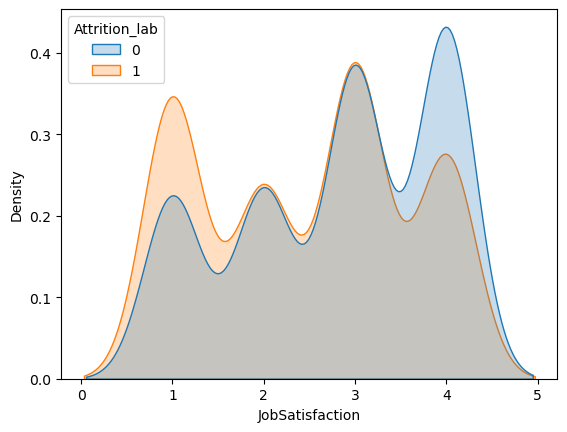

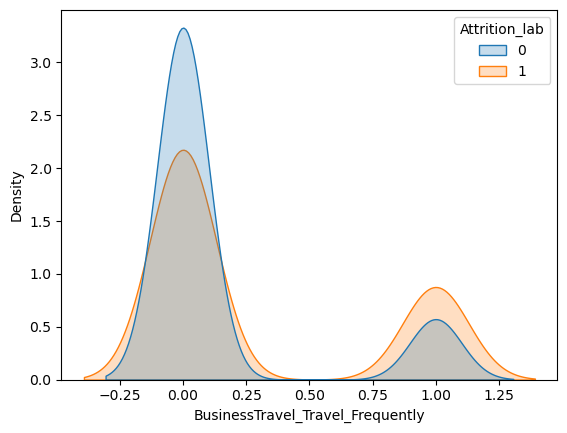

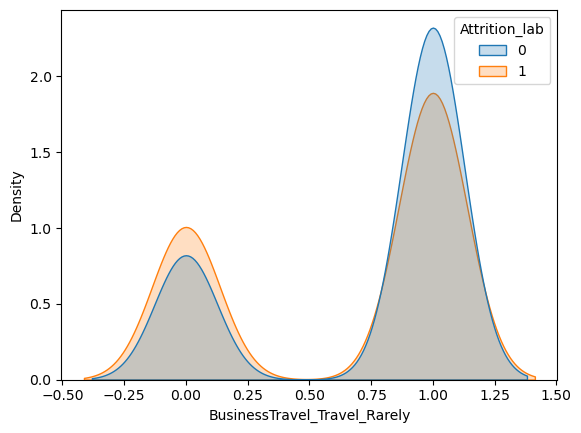

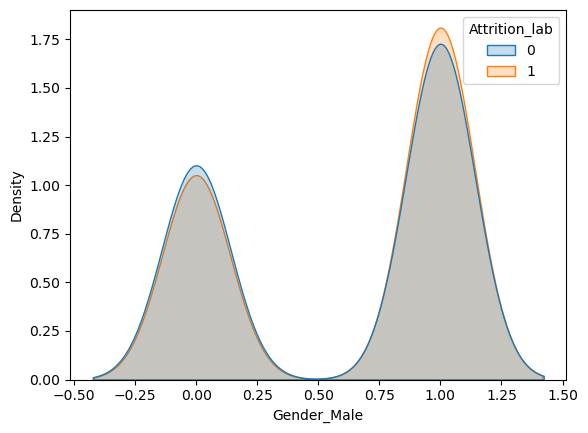

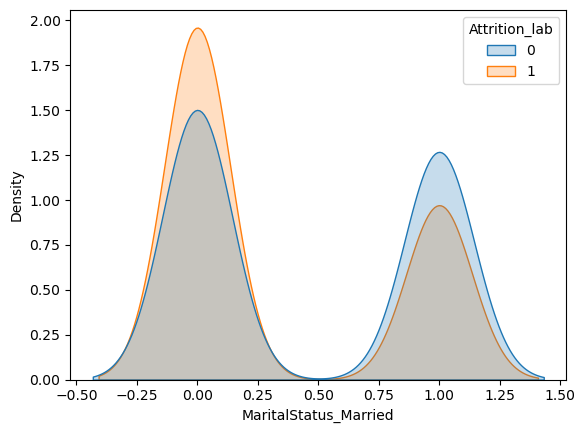

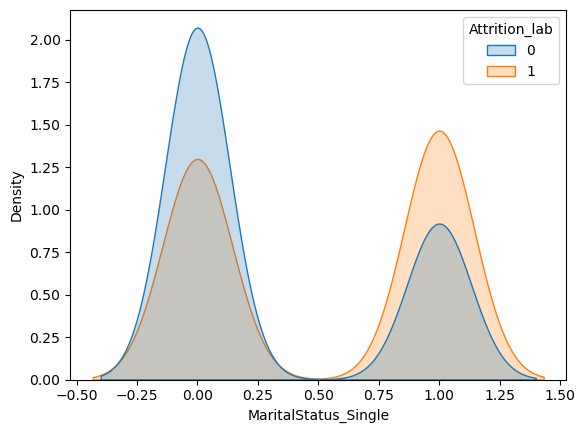

In [129]:
all_features = ['Age', 'DistanceFromHome', 'Education',
'JobLevel', 'Income', 'NumCompaniesWorked','TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'BusinessTravel_Travel_Frequently',
'BusinessTravel_Travel_Rarely', 'Gender_Male', 'MaritalStatus_Married', 'MaritalStatus_Single']

for i in all_features:
    sns.kdeplot(
        data = attrition_train_bal,
        x = i,
        hue = 'Attrition_lab',
        fill = True,
        common_norm = False
    )   
    plt.show()

---

#### Q2 Model Comparison - Choose four variables from the list provided (e.g., `Age`, `Gender`, `JobSatisfaction`, `Income`) and use them to create logistic regression models with the following combinations:
- Model 1: A one-variable model with `Age`.
- Model 2: A two-variable model with `Age` and `Gender`
- Model 3: A three-variable model with `Age`, `Gender`, and `JobSatisfaction`.
- Model 4: An interaction model involving `Age`, `Gender`, `JobSatisfaction`, `Income`, and `Gender:Income`. 
- Compare the validation-set performance of these models using the following metrics: AIC, AUC, Precision & Recall (use p = 0.5 as cutoff). Include tables summarizing the results. 
 Create a graph to visually represent the comparison of the models based on the selected metrics. 

---

#### The first step is to define the features needed for this model

---

In [130]:
model_1_features = ['Age']
model_2_features = ['Age', 'Gender_Male']
model_3_features = ['Age' , 'Gender_Male' , 'JobSatisfaction']

## need to create a new column for Gender:Income (need to do this for both our balanced train set and our X_test_encoded)

attrition_train_bal['Gender:Income'] = attrition_train_bal['Income'] * attrition_train_bal['Gender_Male']
attrition_train['Gender:Income'] = attrition_train['Income'] * attrition_train['Gender_Male']
attrition_test['Gender:Income'] = attrition_test['Income'] * attrition_test['Gender_Male']

model_4_features = ['Age' , 'Gender_Male' , 'JobSatisfaction' , 'Income' , 'Gender:Income' ]

---

#### Additionally, create a predictor column (drop the employee id column, attrition, and work hours columns)

---

In [131]:
predictors = attrition_train_bal.columns.tolist()
### need to remove Attrition, EmployeeID , StandardHours , Attrition_lab
predictors.remove('Attrition_lab')
predictors.remove('Attrition')
predictors.remove('EmployeeID')
predictors.remove('StandardHours')
predictors


['Age',
 'DistanceFromHome',
 'Education',
 'JobLevel',
 'Income',
 'NumCompaniesWorked',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsWithCurrManager',
 'EnvironmentSatisfaction',
 'JobSatisfaction',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Gender_Male',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'Gender:Income']

---

#### Create the models 
- First, we will create the models 
- Then, we will create a model with all the predictors

---

#### Create a function to run each base model

In [132]:
def log_reg_summary(df, response, predictors): 
    model = sm.Logit(df[response], sm.add_constant(df[predictors])).fit()
    print(f"\n=== f1 summary ({len(predictors)} features)===")
    print(model.summary())
    return model


---

#### Model 1

---

In [133]:
print('Unbalanced')
model1_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_1_features)
print('=' * 78)
print('=' * 78)
print('=' * 78)
print('Balanced')
model1 = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_1_features)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.424761
         Iterations 6

=== f1 summary (1 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3085
Method:                           MLE   Df Model:                            1
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                 0.03869
Time:                        15:55:57   Log-Likelihood:                -1311.2
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 9.299e-25
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4516      0.213      2.124      0.034       0.03

---

#### Model 2

---

In [134]:
print('Unbalanced')
model2_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_2_features)
print('=' * 79)
print('=' * 79)
print('=' * 79)
print('Balanced')
model2 = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_2_features)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.424663
         Iterations 6

=== f1 summary (2 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3084
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                 0.03891
Time:                        15:55:57   Log-Likelihood:                -1310.9
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 8.931e-24
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.3929      0.226      1.742      0.082      -0

----

#### Model 3

In [135]:
print('Unbalanced')
model3_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_3_features)
print('=' * 83)
print('=' * 83)
print('=' * 83)
print('Balanced')
model3 = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_3_features)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.419865
         Iterations 6

=== f1 summary (3 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3083
Method:                           MLE   Df Model:                            3
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                 0.04977
Time:                        15:55:57   Log-Likelihood:                -1296.1
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 3.093e-29
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.0431      0.256      4.075      0

---

#### Model 4

---

In [136]:
print('Unbalanced')
model4_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_4_features)
print('=' * 81)
print('=' * 81)
print('=' * 81)
print('Balanced')
model4 = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_4_features)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.419425
         Iterations 6

=== f1 summary (5 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3081
Method:                           MLE   Df Model:                            5
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                 0.05076
Time:                        15:55:57   Log-Likelihood:                -1294.8
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 3.760e-28
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.2014      0.284      4.235      0

---

#### All Predictors

---

In [137]:
print('Unbalanced')
model_all_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , predictors)
print('=' * 81)
print('=' * 81)
print('=' * 81)
print('Balanced')
model_all = log_reg_summary(attrition_train_bal , 'Attrition_lab' , predictors)

Unbalanced
Optimization terminated successfully.
         Current function value: 0.376104
         Iterations 7

=== f1 summary (18 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3068
Method:                           MLE   Df Model:                           18
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1488
Time:                        15:55:57   Log-Likelihood:                -1161.0
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 5.259e-75
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const               

---

# VIF Table to Explore Multicolinearity
#### Now that we have gotten the base models, we can produce a VIF table to explore the VIF values for each variable

---

In [138]:
def vif_table(model):
    X = model.model.exog
    names = model.model.exog_names
    vif_values = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return pd.DataFrame({"variable": names, "VIF": vif_values})

In [139]:
### helper function to print results of all the models
def print_vif(f1):
    vif_df = vif_table(f1)
    return vif_df

---

#### Model 1

---

##### Unbalanced

In [210]:
print_vif(model1_unbalanced)

,variable,VIF
0,const,17.295005
1,Age,1.000000


##### Balanced

In [211]:
print_vif(model1)

,variable,VIF
0,const,14.474254
1,Age,1.000000


---

#### Model 2

---

##### Unbalanced

In [212]:
print_vif(model2_unbalanced)

,variable,VIF
0,const,19.387184
1,Age,1.002585
2,Gender_Male,1.002585


##### Balanced

In [213]:
print_vif(model2)

,variable,VIF
0,const,16.391562
1,Age,1.000784
2,Gender_Male,1.000784


---

### Model 3

---

##### Unbalanced

In [214]:
print_vif(model3_unbalanced)

,variable,VIF
0,const,25.359207
1,Age,1.002587
2,Gender_Male,1.002829
3,JobSatisfaction,1.000243


##### Balanced

In [ ]:
print_vif(model3)

Balanced


,variable,VIF
0,const,21.564091
1,Age,1.001740
2,Gender_Male,1.001115
3,JobSatisfaction,1.001318


---

### Model 4

---

##### Unbalanced

In [ ]:
print_vif(model4_unbalanced)

,variable,VIF
0,const,30.202423
1,Age,1.004074
2,Gender_Male,2.879654
3,JobSatisfaction,1.000432
4,Income,2.519779
5,Gender:Income,4.413857


##### Balanced

In [216]:
print_vif(model4)

,variable,VIF
0,const,27.328612
1,Age,1.007232
2,Gender_Male,2.802673
3,JobSatisfaction,1.004185
4,Income,2.682962
5,Gender:Income,4.546714


----

#### All Features Model

---

##### Unbalanced

In [217]:
print_vif(model_all_unbalanced)

,variable,VIF
0,const,76.115910
1,Age,2.024282
2,DistanceFromHome,1.012427
3,Education,1.009536
4,JobLevel,1.013928
5,Income,2.550961
6,NumCompaniesWorked,1.254810
7,TotalWorkingYears,3.050359
8,TrainingTimesLastYear,1.015776
9,YearsAtCompany,3.395110


##### Balanced

In [218]:
print_vif(model_all)

,variable,VIF
0,const,73.756728
1,Age,2.027865
2,DistanceFromHome,1.043145
3,Education,1.017366
4,JobLevel,1.045889
5,Income,2.734637
6,NumCompaniesWorked,1.290469
7,TotalWorkingYears,3.429992
8,TrainingTimesLastYear,1.043597
9,YearsAtCompany,3.926485


---

#### ROC / AUC / Precision / Recall
- Test balanced/unbalanced trained dataset

---

#### Create a helper function to evaulate the models

In [150]:
def evaulate_model(df , model , response, predictors, score):
    train_probs = model.predict(sm.add_constant(df[predictors]))
    train_pred_class = (train_probs >= score).astype(int)
    cm_train = confusion_matrix(df[response] , train_pred_class)
    precision_train = precision_score(df[response] , train_pred_class)
    recall_train = recall_score(df[response] , train_pred_class)
    print("\nIn-sample confusion matrix (threshold = 0.5):")
    dataframe = pd.DataFrame(
        cm_train,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )
    print(f"\nPrecision (train): {precision_train:.3f}")
    print(f"Recall (train):    {recall_train:.3f}")
    return dataframe

---

#### Model 1 Comparision

---

##### Unbalanced

In [219]:
evaulate_model(attrition_train , model1_unbalanced , 'Attrition_lab',
               model_1_features , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred 0,Pred 1
Actual 0,2589,0
Actual 1,498,0


##### Balanced

In [221]:
evaulate_model(attrition_train_bal , model1 , 'Attrition_lab',
               model_1_features , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.598
Recall (train):    0.687


,Pred 0,Pred 1
Actual 0,268,230
Actual 1,156,342


---

#### Model 2 Comparision

---

##### Unbalanced

In [222]:
evaulate_model(attrition_train , model2_unbalanced , 'Attrition_lab',
               model_2_features , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred 0,Pred 1
Actual 0,2589,0
Actual 1,498,0


##### Balanced

In [223]:
evaulate_model(attrition_train_bal , model2 , 'Attrition_lab',
               model_2_features , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.610
Recall (train):    0.675


,Pred 0,Pred 1
Actual 0,283,215
Actual 1,162,336


---

#### Model 3 Comparision

---

##### Unbalanced

In [224]:
evaulate_model(attrition_train , model3_unbalanced , 'Attrition_lab',
               model_3_features , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred 0,Pred 1
Actual 0,2589,0
Actual 1,498,0


##### Balanced

In [225]:
evaulate_model(attrition_train_bal , model3 , 'Attrition_lab',
               model_3_features , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.620
Recall (train):    0.624


,Pred 0,Pred 1
Actual 0,307,191
Actual 1,187,311


---

#### Model 4 Comparision

---

##### Unbalanced

In [226]:
evaulate_model(attrition_train , model4_unbalanced , 'Attrition_lab',
               model_4_features , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred 0,Pred 1
Actual 0,2589,0
Actual 1,498,0


##### Balanced

In [227]:
evaulate_model(attrition_train_bal , model4 , 'Attrition_lab',
               model_4_features , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.617
Recall (train):    0.635


,Pred 0,Pred 1
Actual 0,302,196
Actual 1,182,316


---

#### All Predictors Model Comparision

---

##### Unbalanced

In [228]:
evaulate_model(attrition_train , model_all_unbalanced , 'Attrition_lab',
               predictors , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.767
Recall (train):    0.159


,Pred 0,Pred 1
Actual 0,2565,24
Actual 1,419,79


##### Balanced

In [229]:
evaulate_model(attrition_train_bal , model_all , 'Attrition_lab',
               predictors , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.687
Recall (train):    0.697


,Pred 0,Pred 1
Actual 0,340,158
Actual 1,151,347


---

#### Create ROC and AUC Curve 

---

In [161]:
def evaluate_model_plot(df, model, response, predictors, score=0.5, model_name='f1', dataset_name='train'):
    train_probs = model.predict(sm.add_constant(df[predictors]))
    train_pred_class = (train_probs >= score).astype(int)
    cm_train = confusion_matrix(df[response], train_pred_class)
    precision_train = precision_score(df[response], train_pred_class)
    recall_train = recall_score(df[response], train_pred_class)
    print("\nIn-sample confusion matrix (threshold = 0.5):")
    dataframe = pd.DataFrame(
        cm_train,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )
    print(f"\nPrecision (train): {precision_train:.3f}")
    print(f"Recall (train):    {recall_train:.3f}")
    
    # ROC & AUC
    fpr, tpr, _ = roc_curve(df[response], train_probs)
    auc_f1 = roc_auc_score(df[response], train_probs)
    
    plt.plot(fpr, tpr, label=f"{model_name} ROC (AUC={auc_f1:.3f})")
    plt.plot([0,1],[0,1], "k--")
    plt.legend(); plt.title(f"{dataset_name} ROC"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.show()
    print(f"AUC ({model_name}, {dataset_name}): {auc_f1:.3f}")
    
    return dataframe, auc_f1

---

#### Model 1

---

##### Unbalanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


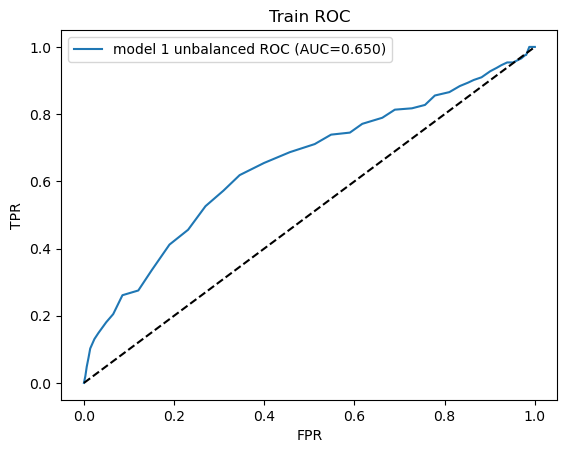

AUC (model 1 unbalanced, Train): 0.650


In [162]:
cm_df_1_un, auc_f1_1_un = evaluate_model_plot(attrition_train, model1_unbalanced, 'Attrition_lab',
    model_1_features  , score=0.5, model_name='model 1 unbalanced', dataset_name='Train')

##### Balanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.598
Recall (train):    0.687


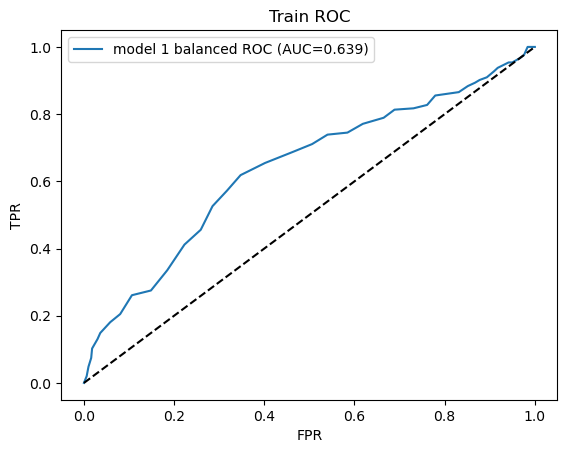

AUC (model 1 balanced, Train): 0.639


In [163]:
cm_df_1_bal, auc_f1_1_bal = evaluate_model_plot(attrition_train_bal, model1, 'Attrition_lab',
    model_1_features  , score=0.5, model_name='model 1 balanced', dataset_name='Train')

---

#### Model 2

---

##### Unbalanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


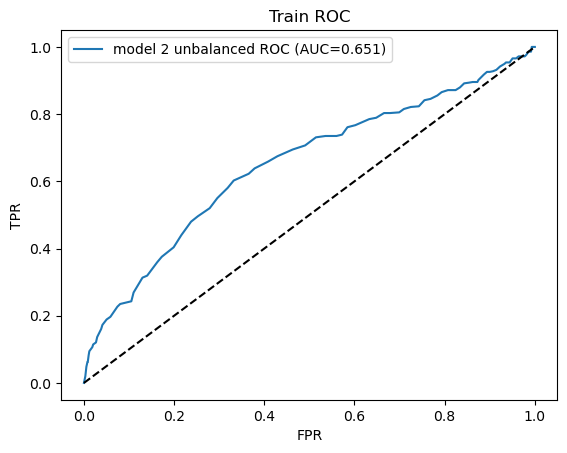

AUC (model 2 unbalanced, Train): 0.651


In [164]:
cm_df_2_un, auc_f1_2_un = evaluate_model_plot(attrition_train, model2_unbalanced, 'Attrition_lab',
    model_2_features  , score=0.5, model_name='model 2 unbalanced', dataset_name='Train')

##### Balanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.610
Recall (train):    0.675


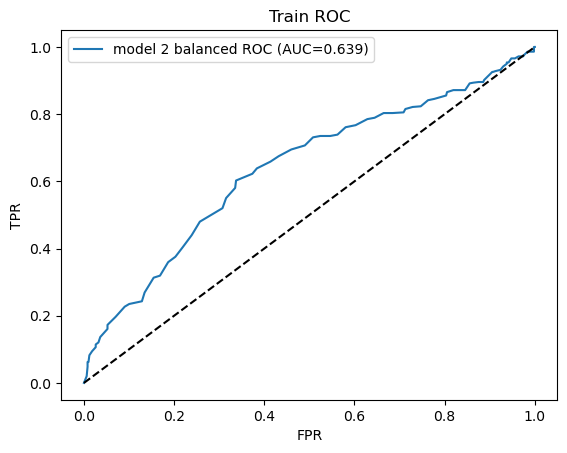

AUC (model 2 balanced, Train): 0.639


In [165]:
cm_df_2_bal, auc_f1_2_bal = evaluate_model_plot(attrition_train_bal, model2, 'Attrition_lab',
    model_2_features  , score=0.5, model_name='model 2 balanced', dataset_name='Train')

---

#### Model 3

---

##### Unbalanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


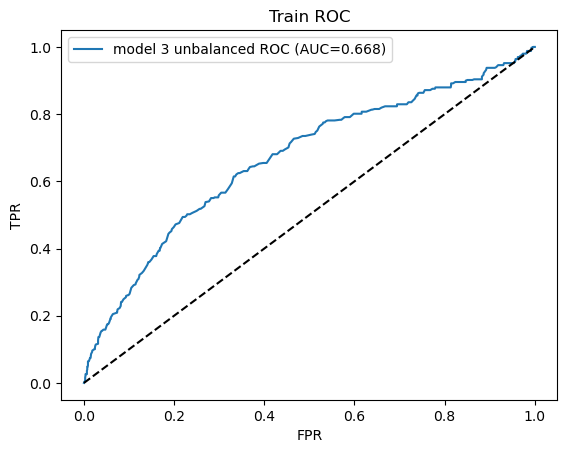

AUC (model 3 unbalanced, Train): 0.668


In [166]:
cm_df_3_un, auc_f1_3_un = evaluate_model_plot(attrition_train, model3_unbalanced, 'Attrition_lab',
    model_3_features  , score=0.5, model_name='model 3 unbalanced', dataset_name='Train')

##### Balanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.620
Recall (train):    0.624


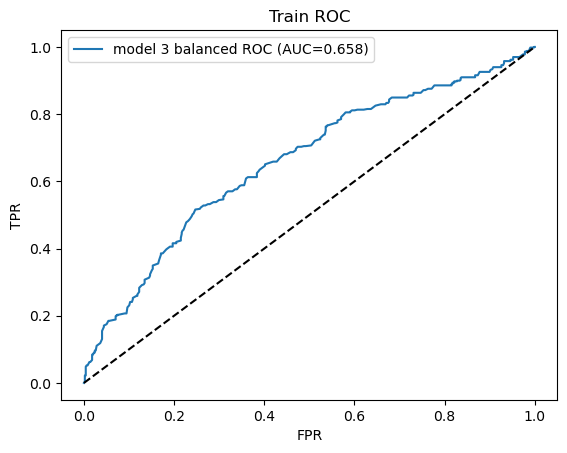

AUC (model 3 balanced, Train): 0.658


In [167]:
cm_df_3_bal, auc_f1_3_bal = evaluate_model_plot(attrition_train_bal, model3, 'Attrition_lab',
    model_3_features  , score=0.5, model_name='model 3 balanced', dataset_name='Train')

---

#### Model 4

---

##### Unbalanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


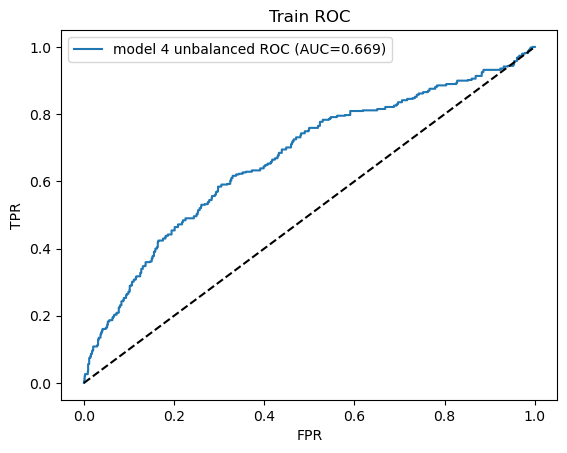

AUC (model 4 unbalanced, Train): 0.669


In [168]:
cm_df_4_un, auc_f1_4_un = evaluate_model_plot(attrition_train, model4_unbalanced, 'Attrition_lab',
    model_4_features  , score=0.5, model_name='model 4 unbalanced', dataset_name='Train')

##### Balanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.617
Recall (train):    0.635


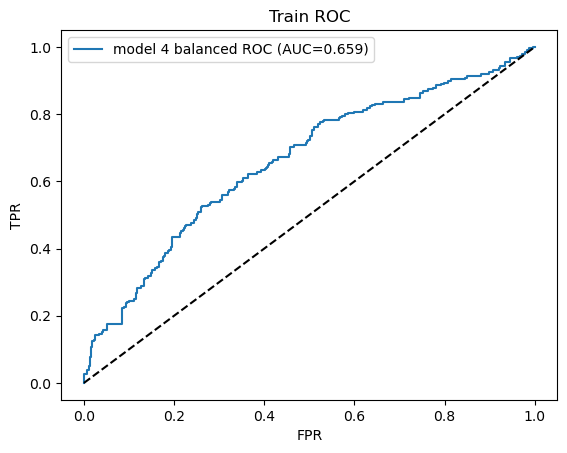

AUC (model 4 balanced, Train): 0.659


In [169]:
cm_df_4_bal, auc_f1_4_bal = evaluate_model_plot(attrition_train_bal, model4, 'Attrition_lab',
    model_4_features  , score=0.5, model_name='model 4 balanced', dataset_name='Train')

---

#### All Predictors Model Comparision

---

##### Unbalanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.767
Recall (train):    0.159


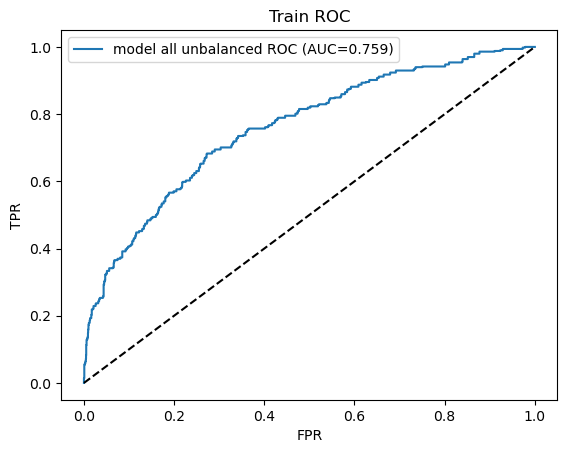

AUC (model all unbalanced, Train): 0.759


In [170]:
cm_df_all_un, auc_f1_all_un = evaluate_model_plot(attrition_train, model_all_unbalanced, 'Attrition_lab',
    predictors  , score=0.5, model_name='model all unbalanced', dataset_name='Train')

##### Balanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.687
Recall (train):    0.697


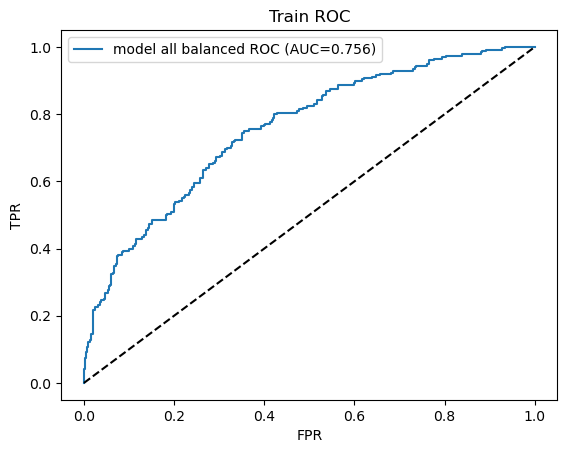

AUC (model all balanced, Train): 0.756


In [171]:
cm_df_all_bal, auc_f1_all_bal = evaluate_model_plot(attrition_train_bal, model_all, 'Attrition_lab',
    predictors  , score=0.5, model_name='model all balanced', dataset_name='Train')

---

# Question 3
#### Predictive Performance - Using the logistic regression models that you have developed, perform a prediction analysis for employee attrition. 
- For each of the four models, calculate the predicted probabilities of employee attrition for the test dataset.
- Calculate predicted probabilities for each model using the test dataset
- Create ROC curve objects for each model
- Create ROC curves for each model to evaluate their discriminatory power in predicting attrition.
- Plot ROC curves for all four models on one plot
- Compare the ROC curves and AUC. Discuss which model appears to be the most effective in distinguishing between employees with and without attrition.

---

#### Test set predictions and evaulations

In [172]:
test_probs1_un = model1_unbalanced.predict(sm.add_constant(attrition_test[model_1_features]))
test_probs1_bal = model1.predict(sm.add_constant(attrition_test[model_1_features]))
auc_test1_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs1_un)
auc_test1_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs1_bal)
test_auc_df_1 = pd.DataFrame({
    "Model": ["model 1 unbalanced", "model 1 balanced"],
    "AUC": [auc_test1_un, auc_test1_bal]
})
test_auc_df_1

,Model,AUC
0,model 1 unbalanced,0.595912
1,model 1 balanced,0.595912


In [173]:
test_probs2_un = model2_unbalanced.predict(sm.add_constant(attrition_test[model_2_features]))
test_probs2_bal = model2.predict(sm.add_constant(attrition_test[model_2_features]))
auc_test2_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs2_un)
auc_test2_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs2_bal)
test_auc_df_2 = pd.DataFrame({
    "Model": ["model 2 unbalanced", "model 2 balanced"],
    "AUC": [auc_test2_un, auc_test2_bal]
})
test_auc_df_2

,Model,AUC
0,model 2 unbalanced,0.596411
1,model 2 balanced,0.596411


In [174]:
test_probs3_un = model3_unbalanced.predict(sm.add_constant(attrition_test[model_3_features]))
test_probs3_bal = model3.predict(sm.add_constant(attrition_test[model_3_features]))
auc_test3_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs3_un)
auc_test3_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs3_bal)
test_auc_df_3 = pd.DataFrame({
    "Model": ["model 3 unbalanced", "model 3 balanced"],
    "AUC": [auc_test3_un, auc_test3_bal]
})
test_auc_df_3

,Model,AUC
0,model 3 unbalanced,0.627129
1,model 3 balanced,0.627661


In [175]:
test_probs4_un = model4_unbalanced.predict(sm.add_constant(attrition_test[model_4_features]))
test_probs4_bal = model4.predict(sm.add_constant(attrition_test[model_4_features]))
auc_test4_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs4_un)
auc_test4_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs4_bal)
test_auc_df_4 = pd.DataFrame({
    "Model": ["model 4 unbalanced", "model 4 balanced"],
    "AUC": [auc_test4_un, auc_test4_bal]
})
test_auc_df_4

,Model,AUC
0,model 4 unbalanced,0.630931
1,model 4 balanced,0.632669


In [176]:
test_probs_all_un = model_all_unbalanced.predict(sm.add_constant(attrition_test[predictors]))
test_probs_all_bal = model_all.predict(sm.add_constant(attrition_test[predictors]))
auc_test_all_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs_all_un)
auc_test_all_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs_all_bal)
test_auc_all = pd.DataFrame({
    "Model": ["model all unbalanced", "model all balanced"],
    "AUC": [auc_test_all_un, auc_test_all_bal]
})
test_auc_all

,Model,AUC
0,model all unbalanced,0.736248
1,model all balanced,0.737994


#### Interesting to note that the unbalanced dataset did better than the balanced dataset

---

#### Test to see if there is a better set of features to use (will be using StepWise Feature Selection)

---

#### Stepwise-like selection with mlxtend (wrapper around sklearn)
#### We use LogisticRegression (sklearn) + AUC scoring. Then refit in statsmodels.

---

#### This takes a long time, so let's do this on a random sample of 1,000 obs

In [230]:
stepwise_model = SFS(
    LogisticRegression(solver="lbfgs", max_iter=1000),
    k_features = "best", # we can let the model choose or set a range as before
    forward = True,
    floating = True,
    scoring = "roc_auc", # maximum AUC
    cv = 5,
    n_jobs = -1 # use all available cores to build models in parallel
)

stepwise_model = stepwise_model.fit(
    attrition_train_bal[predictors],
    attrition_train_bal["Attrition_lab"]
    )

/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

# Get selected predictors

In [231]:
selected_idx = list(stepwise_model.k_feature_idx_)

selected_cols = [predictors[i] for i in selected_idx]

print("Selected features by SFS:", selected_cols)

Selected features by SFS: ['Age', 'Education', 'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'MaritalStatus_Single']


In [232]:
selected_cols

['Age',
 'Education',
 'NumCompaniesWorked',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsWithCurrManager',
 'EnvironmentSatisfaction',
 'JobSatisfaction',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'MaritalStatus_Single']

#### Found the best features to use via Stepwise Selection

---

#### Create a model and test to see the differences between the unbalanced and balanced dataset

---

In [234]:
print('Unbalanced')
modelSFS_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , selected_cols)
print('=' * 81)
print('=' * 81)
print('=' * 81)
print('Balanced')
modelSFS = log_reg_summary(attrition_train_bal , 'Attrition_lab' , selected_cols)

Unbalanced
Optimization terminated successfully.
         Current function value: 0.376818
         Iterations 7

=== f1 summary (12 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3074
Method:                           MLE   Df Model:                           12
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1472
Time:                        17:07:10   Log-Likelihood:                -1163.2
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 1.789e-78
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const               

---

#### Test to see the VIF on the balanced and unbalanced models

---

##### Unbalanced

In [235]:
print_vif(modelSFS_unbalanced)

,variable,VIF
0,const,60.285136
1,Age,2.016395
2,Education,1.005607
3,NumCompaniesWorked,1.243942
4,TotalWorkingYears,3.045344
5,TrainingTimesLastYear,1.009162
6,YearsAtCompany,3.375912
7,YearsWithCurrManager,2.450165
8,EnvironmentSatisfaction,1.005354
9,JobSatisfaction,1.008136


##### Balanced

In [236]:
print_vif(modelSFS)

,variable,VIF
0,const,56.921053
1,Age,1.997237
2,Education,1.010817
3,NumCompaniesWorked,1.261152
4,TotalWorkingYears,3.405283
5,TrainingTimesLastYear,1.027620
6,YearsAtCompany,3.913906
7,YearsWithCurrManager,2.567185
8,EnvironmentSatisfaction,1.028170
9,JobSatisfaction,1.022420


---

#### Test to see the model precision and recall

---

##### Unbalanced

In [237]:
evaulate_model(attrition_train , modelSFS_unbalanced , 'Attrition_lab',
               selected_cols , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.760
Recall (train):    0.153


,Pred 0,Pred 1
Actual 0,2565,24
Actual 1,422,76


##### Balanced

In [238]:
evaulate_model(attrition_train_bal , modelSFS , 'Attrition_lab',
               selected_cols , 0.5)


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.689
Recall (train):    0.693


,Pred 0,Pred 1
Actual 0,342,156
Actual 1,153,345


Exception ignored in: <function ResourceTracker.__del__ at 0x1058e19e0>
Traceback (most recent call last):
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x11c0759e0>
Traceback (most recent call last):
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jacquelinemcginley/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
Chi

##### Unbalanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.760
Recall (train):    0.153


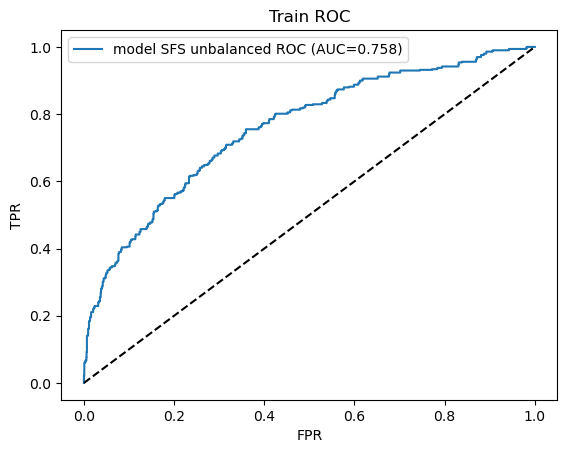

AUC (model SFS unbalanced, Train): 0.758


In [184]:
cm_df_SFS_un, auc_f1_SFS_un = evaluate_model_plot(attrition_train, modelSFS_unbalanced, 'Attrition_lab',
    selected_cols  , score=0.5, model_name='model SFS unbalanced', dataset_name='Train')

##### Balanced


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.689
Recall (train):    0.693


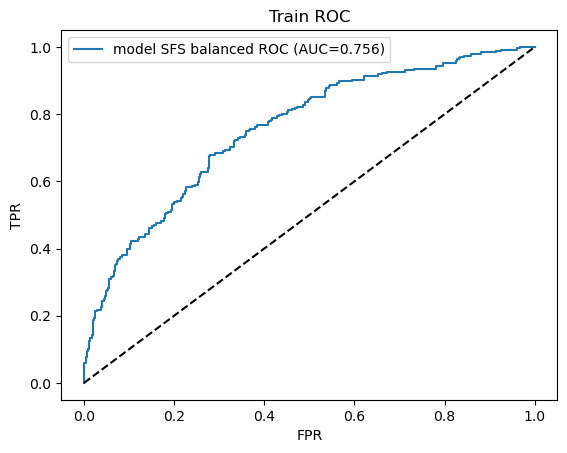

AUC (model SFS balanced, Train): 0.756


In [185]:
cm_df_SFS_bal, auc_f1_SFS_bal = evaluate_model_plot(attrition_train_bal, modelSFS, 'Attrition_lab',
    selected_cols  , score=0.5, model_name='model SFS balanced', dataset_name='Train')

In [186]:
test_probs_SFS_un = modelSFS_unbalanced.predict(sm.add_constant(attrition_test[selected_cols]))
test_probs_SFS_bal = modelSFS.predict(sm.add_constant(attrition_test[selected_cols]))
auc_test_SFS_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs_SFS_un)
auc_test_SFS_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs_SFS_bal)
test_auc_SFS = pd.DataFrame({
    "Model": ["model SFS unbalanced", "model SFS balanced"],
    "AUC": [auc_test_SFS_un, auc_test_SFS_bal]
})
test_auc_SFS

,Model,AUC
0,model SFS unbalanced,0.735634
1,model SFS balanced,0.734391


---

#### Lets try to create a more comprehensive model.
#### Now that we have used SFS to find the best features to use (selected_cols)

#### Explore scaling the data and using pipelines to impute instead of using the medium, will try to feature engineer within the CV
- Recap: the balanced dataset is attrition_train_bal , attrition_test
- model_1_features , model_2_features, model_3_features, model_4_features, predictors , and selected_cols


#### Data Pre-Processing: 

In [239]:
df2 = pd.read_excel('Employee_Data_Project.xlsx')

a_train , a_test = train_test_split(
    df2, 
    test_size=0.3, 
    random_state= 42, 
    stratify=df2['Attrition']
)

a_train['Attrition_lab'] = (a_train['Attrition'] == "Yes").astype(int)
a_test['Attrition_lab'] = (a_test['Attrition'] == "Yes").astype(int)
categorical_columns = ['BusinessTravel', 'Gender', 'MaritalStatus']
a_train = pd.get_dummies(a_train, columns=categorical_columns, drop_first=True, dtype=int)
a_test = pd.get_dummies(a_test, columns = categorical_columns, drop_first= True, dtype = int )
a_train['Gender:Income'] = a_train['Income'] * a_train['Gender_Male']
a_test['Gender:Income'] = a_test['Income'] * a_test['Gender_Male']

#### Class imbalance: downsample the negative class; keep all positives
#### + equal number of negatives

In [240]:
np.random.seed(42)
pos_idx1 = a_train.index[a_train["Attrition_lab"] == 1]
neg_idx1 = a_train.index[a_train["Attrition_lab"] == 0]

keep_neg1= np.random.choice(neg_idx, size=len(pos_idx), replace=False)
keep_idx1 = np.concatenate([pos_idx, keep_neg])

a_train_bal = a_train.loc[keep_idx].copy()

#### Quick look after balancing

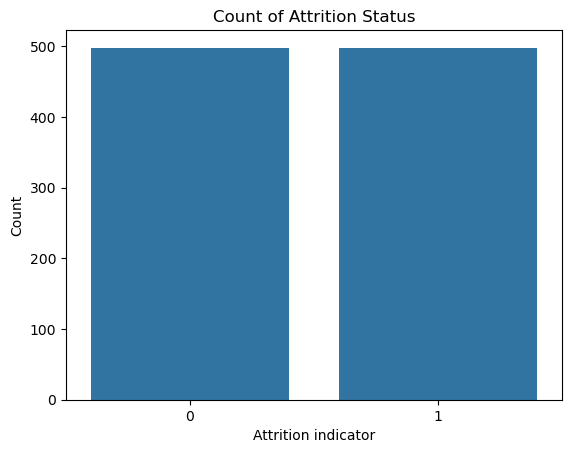

In [241]:
sns.countplot(data = a_train_bal, x="Attrition_lab")
plt.xlabel("Attrition indicator")
plt.ylabel("Count")
plt.title("Count of Attrition Status")
plt.show()

---

#### There will be nulls in this data set
- In pipeline, first thing to do is to use knn_imputer to impute the missing values 
- Next, the features will be scaled using standard scaler 
- Then, the model will be fit using logistic regression

In [242]:
def train_evaulate_knn_logistic_regression(trainset, testset, predictors):
    imputer_knn = KNNImputer(n_neighbors=5)
    trainset[predictors] = imputer_knn.fit_transform(trainset[predictors])
    testset[predictors] = imputer_knn.fit_transform(testset[predictors])

    scaler = StandardScaler()
    trainset[predictors] = scaler.fit_transform(trainset[predictors])
    testset[predictors]  = scaler.transform(testset[predictors])

    log_reg = LogisticRegression(
    max_iter=1000
    )
    log_reg.fit(trainset[predictors], trainset['Attrition_lab'])
    y_pred = log_reg.predict_proba(testset[predictors])[:,1]
    print("Test AUC with KNN imputation:", roc_auc_score(testset['Attrition_lab'], y_pred))

In [190]:
train_evaulate_knn_logistic_regression(a_train , a_test, model_1_features )

Test AUC with KNN imputation: 0.595912109292391


In [191]:
train_evaulate_knn_logistic_regression(a_train_bal , a_test, model_1_features )

Test AUC with KNN imputation: 0.595912109292391


In [192]:
train_evaulate_knn_logistic_regression(a_train , a_test, model_2_features )

Test AUC with KNN imputation: 0.5767774817070592


In [193]:
train_evaulate_knn_logistic_regression(a_train_bal , a_test, model_2_features )

Test AUC with KNN imputation: 0.5551220234318825


In [194]:
train_evaulate_knn_logistic_regression(a_train , a_test, model_3_features )

Test AUC with KNN imputation: 0.6017637355665526


In [195]:
train_evaulate_knn_logistic_regression(a_train_bal , a_test, model_3_features )

Test AUC with KNN imputation: 0.6000719028888043


In [196]:
train_evaulate_knn_logistic_regression(a_train , a_test, model_4_features )

Test AUC with KNN imputation: 0.6060229243327835


In [197]:
train_evaulate_knn_logistic_regression(a_train_bal , a_test, model_4_features )

Test AUC with KNN imputation: 0.6029437888592818


In [198]:
train_evaulate_knn_logistic_regression(a_train , a_test, predictors )

Test AUC with KNN imputation: 0.7384088313665779


In [199]:
train_evaulate_knn_logistic_regression(a_train_bal , a_test, predictors )

Test AUC with KNN imputation: 0.694759548280675


---

#### Stepwise Features

In [200]:
train_evaulate_knn_logistic_regression(a_train , a_test, selected_cols )

Test AUC with KNN imputation: 0.6942858351309056


In [201]:
train_evaulate_knn_logistic_regression(a_train_bal , a_test, selected_cols )

Test AUC with KNN imputation: 0.6918918918918919


---

In [202]:
def get_roc(trainset, testset, features):
    df_train = trainset.copy()
    df_test = testset.copy()
    # Impute
    imputer = KNNImputer(n_neighbors=5)
    df_train[features] = imputer.fit_transform(df_train[features])
    df_test[features] = imputer.transform(df_test[features]) 
    # Scale
    scaler = StandardScaler()
    df_train[features] = scaler.fit_transform(df_train[features])
    df_test[features] = scaler.transform(df_test[features]) 
    # Train
    model = LogisticRegression(max_iter=1000)
    model.fit(df_train[features], df_train['Attrition_lab'])
    # Predict on TEST set
    y_pred = model.predict_proba(df_test[features])[:, 1]  
    # ROC
    fpr, tpr, _ = roc_curve(df_test['Attrition_lab'], y_pred)
    auc = roc_auc_score(df_test['Attrition_lab'], y_pred) 
    return fpr, tpr, auc

---

#### Create Plots

---

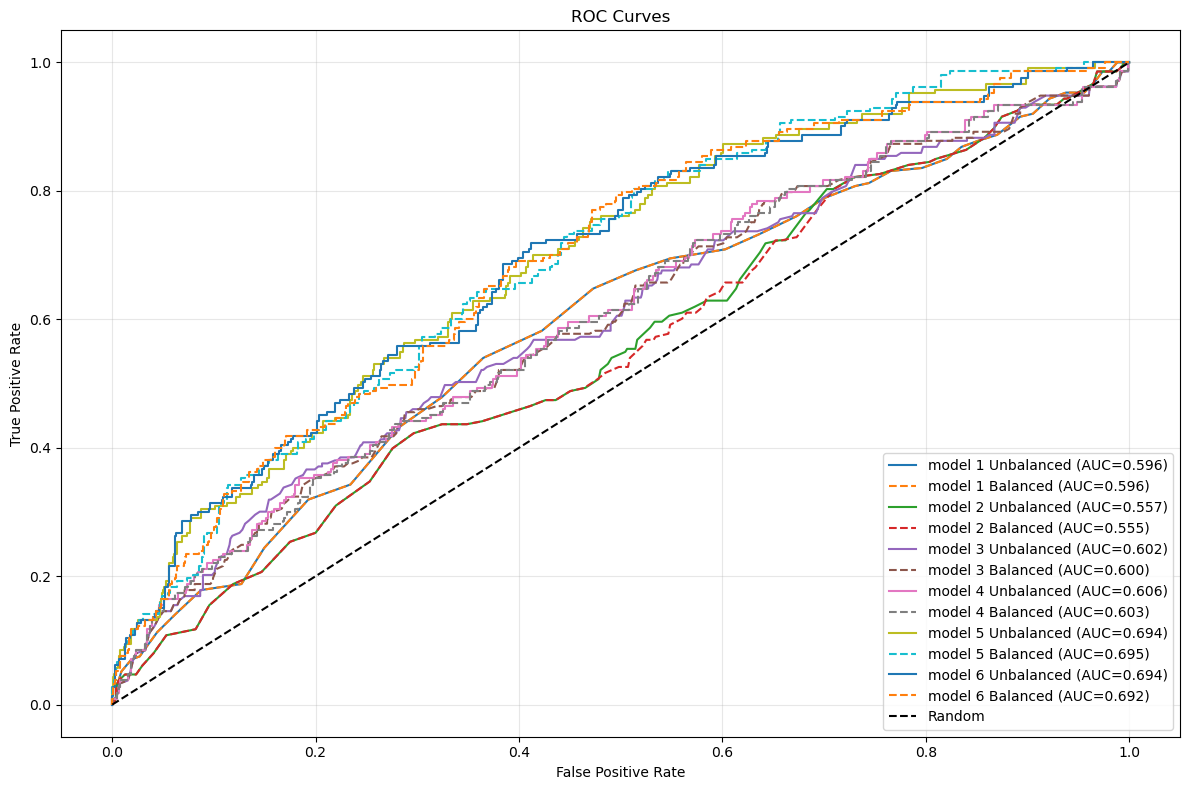

In [203]:
models = {
    'model 1' : model_1_features, 
    'model 2' : model_2_features,
    'model 3' : model_3_features, 
    'model 4' : model_4_features, 
    'model 5' : predictors,
    'model 6' : selected_cols
}
fig, ax = plt.subplots(figsize=(12, 8))

for name, features in models.items():
    # Unbalanced
    fpr_u, tpr_u, auc_u = get_roc(a_train, a_test, features)
    ax.plot(fpr_u, tpr_u, linestyle='-', label=f'{name} Unbalanced (AUC={auc_u:.3f})')
    # Balanced
    fpr_b, tpr_b, auc_b = get_roc(a_train_bal, a_test, features)
    ax.plot(fpr_b, tpr_b, linestyle='--', label=f'{name} Balanced (AUC={auc_b:.3f})')
# Random classifier
ax.plot([0, 1], [0, 1], 'k--', label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [204]:
# define our knn imputer and apply it to numeric columns
imputer_knn = KNNImputer(n_neighbors=5)

a_train[selected_cols] = imputer_knn.fit_transform(a_train[selected_cols])
a_test[selected_cols] = imputer_knn.transform(a_test[selected_cols])

# standardize variables as well
scaler = StandardScaler()
a_train[selected_cols] = scaler.fit_transform(a_train[selected_cols])
a_test[selected_cols]  = scaler.transform(a_test[selected_cols])

# train model
log_reg = LogisticRegression(
    max_iter=1000
)

log_reg.fit(a_train[selected_cols], a_train['Attrition_lab'])

# predict and evaluate on test set
y_pred = log_reg.predict_proba(a_test[selected_cols])[:,1]

print("Test AUC with KNN imputation:", roc_auc_score(a_test['Attrition_lab'], y_pred))

Test AUC with KNN imputation: 0.6942858351309056


In [205]:
# define our knn imputer and apply it to numeric columns
imputer_knn = KNNImputer(n_neighbors=5)

a_train_bal[selected_cols] = imputer_knn.fit_transform(a_train_bal[selected_cols])
a_test[selected_cols] = imputer_knn.transform(a_test[selected_cols])

# standardize variables as well
scaler = StandardScaler()
a_train_bal[selected_cols] = scaler.fit_transform(a_train_bal[selected_cols])
a_test[selected_cols]  = scaler.transform(a_test[selected_cols])

# train model
log_reg = LogisticRegression(
    max_iter=1000
)

log_reg.fit(a_train_bal[selected_cols], a_train_bal['Attrition_lab'])

# predict and evaluate on test set
y_pred = log_reg.predict_proba(a_test[selected_cols])[:,1]

print("Test AUC with KNN imputation:", roc_auc_score(a_test['Attrition_lab'], y_pred))

Test AUC with KNN imputation: 0.6918918918918919
